In [ ]:
from google.colab import files
uploaded = files.upload()


Saving l1_l2_featured_file.csv to l1_l2_featured_file.csv


# This is revised version of code (Roullet Wheel Method)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import random

# Load Data
file_path = "l1_l2_featured_file.csv"
df = pd.read_csv(file_path)
X = df.iloc[:, :-1].values  # First 20 columns as features
y = df.iloc[:, -1].values   # Last column as target

# Normalize Data
scaler_X = StandardScaler()
#scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
#y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Define the problem constraints
num_features = 20  # Number of input features
min_layers = 2
max_layers = 6
min_neurons = 10
max_neurons = 500
population_size = 10
generations = 20
mutation_rate = 0.2
tournament_size = 3

def evaluate_solution(individual):
    num_layers, num_neurons = individual
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    print(num_layers, num_neurons)
    # Build hidden layers
    for i in range(num_layers):
        model.add(Dense(num_neurons[i], activation='relu'))

    # Output layer for regression
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(), loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    y_pred = model.predict(X_test).flatten()
    r2 = r2_score(y_test, y_pred)
    print(r2)
    return r2

# Generate initial population
def initialize_population():
    population = []
    for _ in range(population_size):
        m = random.randint(min_layers, max_layers)
        n_i = [random.randint(min_neurons, max_neurons) for _ in range(m)]
        population.append((m, n_i)) # Store as tuple (num_layers, num_neurons_list)
    return population

# Tournament Selection
def tournament_selection(population, scores):
    selected = random.sample(list(zip(population, scores)), tournament_size)
    best_individual = max(selected, key=lambda x: x[1])[0]
    return best_individual

def crossover(parent1, parent2):
    m1, n1 = parent1
    m2, n2 = parent2

    # Choose a new number of layers from either parent
    m_new = random.choice([m1, m2])

    # Pad or trim both neuron lists to match m_new length
    def adjust_layers(n, m_target):
        if len(n) < m_target:
            # Pad by repeating the last neuron count
            return n + [n[-1]] * (m_target - len(n)) if n else [random.randint(min_neurons, max_neurons)] * m_target
        else:
            return n[:m_target]

    n1_adjusted = adjust_layers(list(n1), m_new) # Ensure lists are mutable
    n2_adjusted = adjust_layers(list(n2), m_new)

    # Two-point crossover
    if m_new > 1: # Ensure there are at least two points for crossover
        p1, p2 = sorted(random.sample(range(m_new), 2))
        child1_n = n1_adjusted[:p1] + n2_adjusted[p1:p2] + n1_adjusted[p2:]
        child2_n = n2_adjusted[:p1] + n1_adjusted[p1:p2] + n2_adjusted[p2:]
    else: # Single point crossover or no crossover for 1 layer
        p1 = random.randint(0, m_new)
        child1_n = n1_adjusted[:p1] + n2_adjusted[p1:]
        child2_n = n2_adjusted[:p1] + n1_adjusted[p1:]


    return (m_new, child1_n), (m_new, child2_n)

# Mutation:
def mutate(individual):
    m, n = individual
    n_mutated = list(n) # Ensure the list is mutable
    if random.random() < mutation_rate and n_mutated: # Check if n_mutated is not empty
        index = random.randint(0, len(n_mutated) - 1)  # Select a random neuron index
        original_value = n_mutated[index]
        change = int(random.uniform(-0.2, 0.2) * original_value)  # Calculate the change (-20% to 20%)
        n_mutated[index] = max(min_neurons, original_value + change)  # Apply the change, ensure within bounds
    return (m, n_mutated)


def roulette_wheel_selection(population_score):
    # population_score = [(individual, score), ...]
    individuals = [ind for ind, _ in population_score]
    scores = [sc for _, sc in population_score]

    # Shift scores if any are negative (to keep probabilities valid)
    min_score = min(scores)
    if min_score < 0:
        scores = [s - min_score + 1e-6 for s in scores]

    total = sum(scores)
    if total == 0:
        # If all scores are 0 → uniform selection
        probs = [1/len(scores)] * len(scores)
    else:
        probs = [s/total for s in scores]

    parent_pairs = []
    # Ensure population_size is even for pairing
    num_pairs = population_size // 2
    if population_size % 2 != 0:
        print("Warning: population_size is odd. One individual will not be paired for crossover.")
        num_pairs = (population_size - 1) // 2


    for _ in range(num_pairs):
        # Select two distinct parents based on probabilities
        if len(individuals) > 1:
            p1, p2 = np.random.choice(len(individuals), size=2, p=probs, replace=False)
            parent_pairs.append((individuals[p1], individuals[p2]))
        elif len(individuals) == 1:
             # If only one individual left, cannot form a pair
             break


    return parent_pairs

# Genetic Algorithm
def genetic_algorithm():
    population = initialize_population()

    best_solution = None
    best_score = -np.inf

    for gen in range(generations):
        scores = [evaluate_solution(ind) for ind in population]
        population_score = list(zip(population, scores))

        # Track best
        for ind, score in population_score:
            if score > best_score:
                best_solution, best_score = ind, score

        # Selection + offspring
        new_population = []
        parent_pairs = roulette_wheel_selection(population_score)
        for parent1, parent2 in parent_pairs:
            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1)
            child2 = mutate(child2)
            new_population.extend([child1, child2])

        population = new_population
        print(f"Generation {gen}: Best so far = {best_solution} with score {best_score}")

    return best_solution, best_score

# Run the GA
best_solution, best_score = genetic_algorithm()
print("Best Network Configuration:", best_solution)
print("Best R2 Score:", best_score)

6 [211, 419, 230, 311, 398, 387]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
0.8637561261652984
5 [433, 237, 118, 157, 126]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step
0.5728938653239254
5 [27, 476, 292, 337, 329]


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
0.5298882306877795
2 [283, 169]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
-2.6949365376958627
3 [355, 323, 406]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step
0.4095744971829097
3 [384, 225, 494]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step
0.27346818355608105
5 [278, 46, 419, 27, 123]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 478ms/step
0.8476392838822401
5 [66, 88, 446, 325, 461]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step
0.7554676776802025
6 [244, 201, 332, 88, 391, 341]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
0.8383312303993168
2 [477, 372]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
-0.6721605094587315
Generation 0: Best so far = (6, [211, 419, 230, 311, 398, 387]) with score 0.8637561261652984
6 [211, 237, 118, 157, 126, 126]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step
0.8349040734289324
6 [433, 419, 230, 311, 398, 387]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
0.8778352032172235
5 [66, 476, 446, 365, 461]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 447ms/step
0.6249357344165791
5 [27, 88, 246, 337, 329]


# This is primary version of code

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import random

# Load Data
file_path = "l1_l2_featured_file.csv"
df = pd.read_csv(file_path)
X = df.iloc[:, :-1].values  # First 20 columns as features
y = df.iloc[:, -1].values   # Last column as target

# Normalize Data
scaler_X = StandardScaler()
#scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
#y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Define the problem constraints
num_features = 20   # Number of input features
min_layers = 2
max_layers = 6
min_neurons = 10
max_neurons = 500
population_size = 10
generations = 20
mutation_rate = 0.2
tournament_size = 3

# Objective function (Example: Minimizing negative R2 score)
def evaluate_solution(m, n_i):
    num_layers, num_neurons = m, n_i
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    print(m, n_i)
    for i in range(num_layers):
        model.add(Dense(n_i[i], activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(), loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    y_pred = model.predict(X_test).flatten()
    r2 = r2_score(y_test, y_pred)
    print(r2)
    return r2   # Minimize negative R² score

# Generate initial population
def initialize_population():
    population = []
    for _ in range(population_size):
        m = random.randint(min_layers, max_layers)
        n_i = [random.randint(min_neurons, max_neurons) for _ in range(m)]
        population.append((m, n_i))
    return population

# Tournament Selection
def tournament_selection(population, scores):
    selected = random.sample(list(zip(population, scores)), tournament_size)
    best_individual = max(selected, key=lambda x: x[1])[0]
    return best_individual

def crossover(parent1, parent2):
    m1, n1 = parent1
    m2, n2 = parent2
    # Choose a new number of layers from either parent
    m_new = random.choice([m1, m2])

    # Pad or trim both neuron lists to match m_new length
    def adjust_layers(n, m_target):
        if len(n) < m_target:
            return n + [n[-1]] * (m_target - len(n))  # Repeat last neuron count
        else:
            return n[:m_target]

    n1 = adjust_layers(n1, m_new)
    n2 = adjust_layers(n2, m_new)

    # Two-point crossover
    if m_new > 2:
        p1, p2 = sorted(random.sample(range(m_new), 2))
        child1 = n1[:p1] + n2[p1:p2] + n1[p2:]
        child2 = n2[:p1] + n1[p1:p2] + n2[p2:]
    else:
        child1, child2 = n1, n2

    return (m_new, child1), (m_new, child2)

# Mutation:
def mutate(individual):
    m, n = individual
    if random.random() < mutation_rate:
        index = random.randint(0, len(n) - 1)  # Select a random neuron index
        original_value = n[index]
        change = int(random.uniform(0, 0.2) * original_value)  # Calculate the change (0-20%)
        n[index] = original_value + change  # Apply the change
    return (m, n)

# Genetic Algorithm
def genetic_algorithm():
    population = initialize_population()
    all_scores = []

    for gen in range(generations):
        scores = [evaluate_solution(m, n) for m, n in population]
        local_population = list(zip(population, scores))
        all_scores.append(local_population)

        new_population = []
        for _ in range(population_size // 2):
            # Select parents
            parent1 = tournament_selection(population, scores)
            parent2 = tournament_selection(population, scores)

            # Apply crossover
            child1, child2 = crossover(parent1, parent2)

            # Apply mutation
            child1 = mutate(child1)
            child2 = mutate(child2)

            new_population.extend([child1, child2])

        population = new_population
        print(new_population)

    # Return the best solution
    final_scores = [evaluate_solution(m, n) for m, n in population]
    best_index = np.argmax(final_scores)
    return population[best_index], final_scores[best_index]

# Run the GA
best_solution, best_score = genetic_algorithm()
print("Best Network Configuration:", best_solution)
print("Best R2 Score:", best_score)


5 [415, 110, 354, 423, 201]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
0.7652263735188078
5 [32, 104, 364, 14, 397]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 409ms/step
0.8623026049210023
6 [214, 142, 206, 382, 58, 464]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
0.8673798903429976
4 [390, 499, 488, 385]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step
0.5734820739768924
3 [398, 167, 258]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 355ms/step
0.22079610892771928
3 [400, 92, 237]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step
0.34196646148894316
6 [412, 88, 482, 250, 424, 341]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
0.8254598891193622
4 [158, 367, 114, 140]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 456ms/step
0.4633766036721815
3 [452, 11, 494]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step
0.787930487885549
4 [476, 296, 406, 125]
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
0.7576749968336867
[(6, [412, 88, 354, 423, 201, 341]), (6, [415, 110, 482, 250, 491, 201]), (6, [415, 142, 206, 423, 201, 201]), (6, [214, 110, 354, 382, 58, 464]), (5, [32, 104, 206, 14, 397]), (5,

# This is final Neural Network that worked out well

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import random
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

# Load Data
file_path = "l1_l2_featured_file.csv"
df = pd.read_csv(file_path)
X = df.iloc[:, :-1].values  # First 20 columns as features
y = df.iloc[:, -1].values   # Last column as target

# Normalize Data
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Define the model
final_model = Sequential()
final_model.add(Input(shape=(X_train.shape[1],)))
final_model.add(Dense(449, activation='relu'))
final_model.add(Dense(24, activation='relu'))
final_model.add(Dense(500, activation='relu'))
final_model.add(Dense(385, activation='relu'))
final_model.add(Dense(1, activation='linear'))  # Output layer

# Compile the model
final_model.compile(optimizer=Adam(), loss='mse')

# Train the model
final_model.fit(X_train, y_train, epochs=60, batch_size=50, verbose=1)

# Predict on the test set
y_pred = final_model.predict(X_test).flatten()

# Calculate R2 score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# --- Analyze Model Performance and Residual Plots ---

Epoch 1/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 358ms/step - loss: 0.9963
Epoch 2/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9722
Epoch 3/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5912
Epoch 4/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3708
Epoch 5/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2616
Epoch 6/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1274
Epoch 7/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0818
Epoch 8/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0646
Epoch 9/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0605
Epoch 10/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0344
Epoch 11/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0309
Epoch 12/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0232
Epoch 13/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0144
Epoch 14/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0107
Epoch 15/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0084
Epoch 16/60
3/3 ━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

y_test_unscaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_unscaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
# Create DataFrame
df = pd.DataFrame({
    'Actual_Wear': y_test_unscaled,
    'Predicted_Wear': y_pred_unscaled
})

# Save to CSV
df.to_csv(r"predicted_vs_actual_of_ANN.csv", index=False)

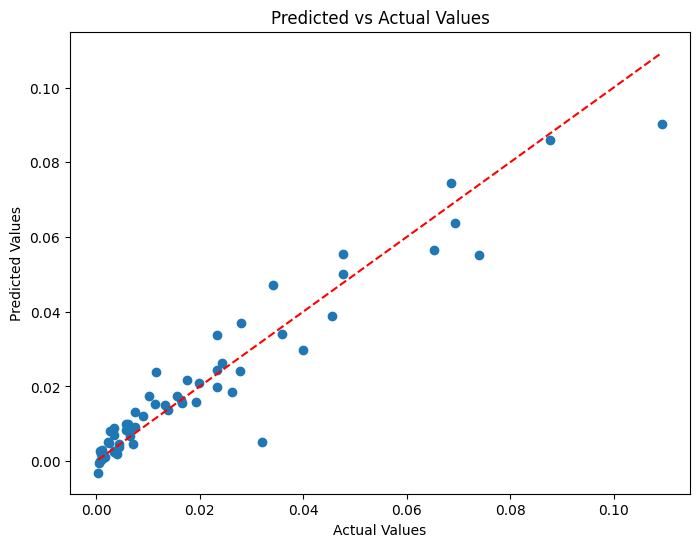

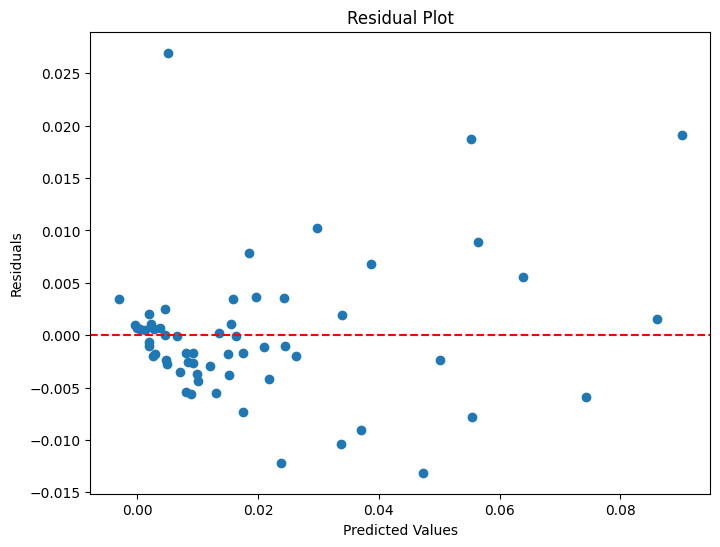

In [ ]:
# Unscale y_test and y_pred
y_test_unscaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_unscaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

# Plot predicted vs actual values (unscaled)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_unscaled, y_pred_unscaled)
plt.plot([min(y_test_unscaled), max(y_test_unscaled)], [min(y_test_unscaled), max(y_test_unscaled)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.savefig("predicted_vs_actual_unscaled.png")

# Plot residuals (unscaled)
residuals_unscaled = y_test_unscaled - y_pred_unscaled
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_unscaled, residuals_unscaled)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_plot_unscaled.png")

# --- Represent the Neural Network ---
# plot_model(final_model, to_file='neural_network.png', show_shapes=True, show_layer_names=True)

In [ ]:
from google.colab import files
uploaded_1 = files.upload()

Saving wear_of_all_simulation.csv to wear_of_all_simulation.csv


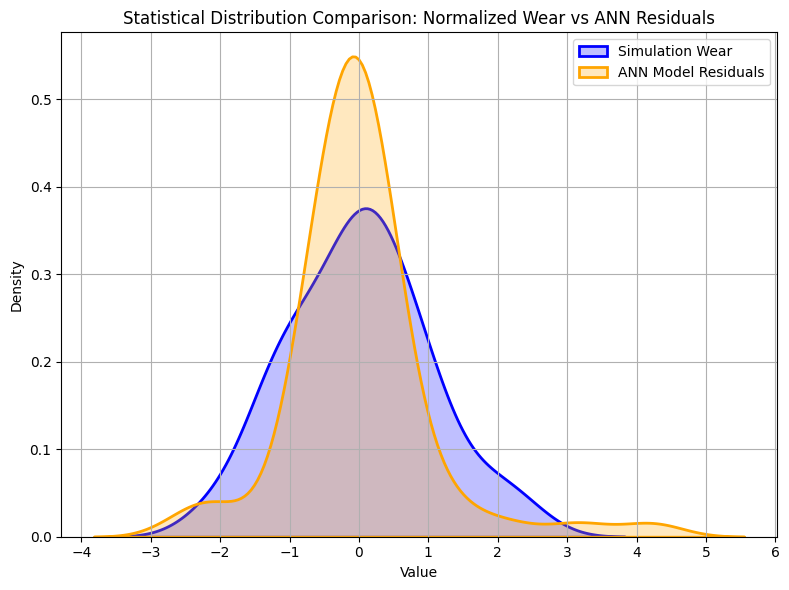

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Step 1: Load repeated EDEM wear data
wear_df = pd.read_csv("wear_of_all_simulation.csv")  # Replace with actual filename
wear_values = wear_df.iloc[:, 0].values.reshape(-1, 1)  # Assuming wear is in first column

# Step 2: Normalize wear values
scaler_wear = StandardScaler()
wear_normalized = scaler_wear.fit_transform(wear_values).flatten()

# Step 3: Assume you already have ANN residuals
# residuals_unscaled = <your residuals>
scaler_residual = StandardScaler()
residual_normalized = scaler_residual.fit_transform(residuals_unscaled.reshape(-1, 1)).flatten()

# Step 4: Plot KDE comparison
plt.figure(figsize=(8, 6))
sns.kdeplot(wear_normalized, label='Simulation Wear', fill=True, color='blue', linewidth=2)
sns.kdeplot(residual_normalized, label='ANN Model Residuals', fill=True, color='orange', linewidth=2)
plt.xlabel('Value')
plt.ylabel('Density')
plt.xticks(np.linspace(-4, 6, 11))
plt.title('Statistical Distribution Comparison: Normalized Wear vs ANN Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("kde_Sim_and_ANN.png")
plt.show()
